# Data Warehouse: European Fashion Store

**Proyek UTS Business Intelligence — ETL & Star Schema**

Notebook ini memuat proses lengkap **Extract, Transform, Load (ETL)** untuk membangun data warehouse dari dataset European Fashion Store (Kaggle). Output berupa star schema dengan tabel dimensi dan fakta yang siap untuk analisis bisnis.

**Alur:** Setup → Extract → Transform → Load → Analisis

## Setup

Clone repo dan set path ke folder dataset. Jika sudah clone manual, cukup jalankan baris `BASE_PATH` saja.

In [14]:
!git clone https://github.com/ariscandra/bi-uts-dw-european-fashion-store.git
BASE_PATH = '/content/bi-uts-dw-european-fashion-store/dataset'

Cloning into 'bi-uts-dw-european-fashion-store'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 62.96 KiB | 10.49 MiB/s, done.


## 1. Extract

Membaca 7 file CSV dari dataset European Fashion Store ke DataFrame pandas.

### 1.1 Memuat dan Membaca CSV

In [15]:
import pandas as pd

sales = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_sales.csv')
sales_items = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_salesitems.csv')
customers = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_customers.csv')
products = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_products.csv')
channels = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_channels.csv')
campaigns = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_campaigns.csv')
stock = pd.read_csv(f'{BASE_PATH}/dataset_fashion_store_stock.csv')

print('Sales:', sales.shape)
print('Sales items:', sales_items.shape)
print('Customers:', customers.shape)
print('Products:', products.shape)
print('Channels:', channels.shape)
print('Campaigns:', campaigns.shape)
print('Stock:', stock.shape)

Sales: (905, 7)
Sales items: (2253, 13)
Customers: (1000, 4)
Products: (500, 9)
Channels: (2, 2)
Campaigns: (2, 2)
Stock: (2, 2)


### 1.2 Pengecekan Struktur

Preview beberapa baris dari setiap tabel untuk memastikan data terbaca dengan benar.

**Tabel Sales**

In [16]:
sales.head()

,sale_id,channel,discounted,total_amount,sale_date,customer_id,country
0,10,E-commerce,0,299.70,2025-05-21,195,France
1,100,App Mobile,0,681.05,2025-04-21,518,Germany
2,1000,E-commerce,0,324.50,2025-05-20,439,Germany
3,1001,E-commerce,0,287.85,2025-04-05,349,Germany
4,1003,App Mobile,0,430.64,2025-06-06,727,Portugal


**Tabel Sales Items**

In [17]:
sales_items.head()

,item_id,sale_id,product_id,quantity,original_price,unit_price,discount_applied,discount_percent,discounted,item_total,sale_date,channel,channel_campaigns
0,2270,658,403,1,81.80,81.80,0.0,0.00%,0,81.80,2025-06-16,App Mobile,App Mobile
1,1170,336,284,1,81.79,81.79,0.0,0.00%,0,81.79,2025-06-17,E-commerce,Website Banner
2,2496,1255,71,1,80.76,80.76,0.0,0.00%,0,80.76,2025-04-16,App Mobile,App Mobile
3,1273,331,98,1,78.52,78.52,0.0,0.00%,0,78.52,2025-05-06,App Mobile,App Mobile
4,1829,1079,98,1,78.52,78.52,0.0,0.00%,0,78.52,2025-06-15,App Mobile,App Mobile


**Tabel Customers**

In [18]:
customers.head()

,customer_id,country,age_range,signup_date
0,1,France,56-65,2025-04-24
1,2,France,36-45,2025-02-24
2,3,Netherlands,46-55,2024-04-12
3,4,Italy,36-45,2025-03-11
4,5,Spain,26-35,2025-04-26


**Tabel Products**

In [19]:
products.head()

,product_id,product_name,category,brand,color,size,catalog_price,cost_price,gender
0,1,Soft Wrap Dress,Dresses,Tiva,Green,S,40.41,20.70,Female
1,2,Soft Wrap Tee,T-Shirts,Tiva,White,S,78.45,53.76,Female
2,3,Soft Linen Tee,T-Shirts,Tiva,Green,XL,23.90,14.81,Female
3,4,Soft Ribbed Tee,T-Shirts,Tiva,White,S,60.00,34.78,Female
4,5,Soft Wrap Trousers,Pants,Tiva,Blue,M,36.84,16.46,Female


**Tabel Channels**

In [20]:
channels.head()

,channel,description
0,E-commerce,Official online store
1,App Mobile,Brand mobile app


**Tabel Campaigns**

In [21]:
campaigns.head()

,campaign_id,campaign_name,start_date,end_date,channel,discount_type,discount_value
0,1,Spring Flash Sale,2025-04-01,2025-04-07,Email,Percentage,10.00%
1,2,Easter Promotion,2025-04-08,2025-04-15,Social Media,Fixed,10
2,3,Mother's Day Campaign,2025-05-01,2025-05-09,Email,Percentage,25.00%
3,4,Mid-Season Clearance,2025-05-10,2025-05-19,App Mobile,Percentage,30.00%
4,5,TIVA Week,2025-05-20,2025-05-31,Social Media,Percentage,30.00%


**Tabel Stock**

In [22]:
stock.head()

,country,product_id,stock_quantity
0,France,1,61
1,France,2,24
2,France,3,81
3,France,4,70
4,France,5,30


## 2. Transform

Membersihkan data, membuat tabel dimensi (dim_customer, dim_product, dim_date, dim_channel), dan tabel fakta (fact_sales) sesuai star schema.

### 2.1 Konversi Tipe Data

Mengubah kolom tanggal dari string ke format datetime agar bisa diolah.

In [23]:
sales['sale_date'] = pd.to_datetime(sales['sale_date'])
sales_items['sale_date'] = pd.to_datetime(sales_items['sale_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
print('Konversi tanggal selesai.')

Konversi tanggal selesai.


### 2.2 Validasi Data

Memeriksa duplikat dan nilai kosong (missing values).

In [25]:
print('Duplikat sale_id:', sales.duplicated(subset=['sale_id']).sum())
print('Duplikat item_id:', sales_items.duplicated(subset=['item_id']).sum())
print('Missing di sales:', sales.isnull().sum().sum())
print('Missing di sales_items:', sales_items.isnull().sum().sum())

Duplikat sale_id: 0
Duplikat item_id: 0
Missing di sales: 0
Missing di sales_items: 0


### 2.3 Membuat dim_date

Tabel dimensi tanggal berisi semua tanggal unik dari transaksi beserta atribut (tahun, bulan, kuartal) untuk analisis.

In [26]:
all_dates = pd.concat([sales['sale_date'], sales_items['sale_date']]).drop_duplicates()
all_dates = pd.to_datetime(all_dates).dt.normalize()
date_range = pd.DataFrame({'date': sorted(all_dates.unique())})
date_range['date_key'] = pd.to_datetime(date_range['date']).dt.strftime('%Y%m%d').astype(int)
date_range['year'] = pd.to_datetime(date_range['date']).dt.year
date_range['month'] = pd.to_datetime(date_range['date']).dt.month
date_range['month_name'] = pd.to_datetime(date_range['date']).dt.month_name()
date_range['day_of_week'] = pd.to_datetime(date_range['date']).dt.dayofweek
date_range['quarter'] = pd.to_datetime(date_range['date']).dt.quarter
date_range['is_weekend'] = date_range['day_of_week'].isin([5, 6]).astype(int)
dim_date = date_range
print('dim_date:', len(dim_date), 'baris')

dim_date: 51 baris


### 2.4 Membuat dim_customer, dim_product, dim_channel

Menambah surrogate key (customer_key, product_key, channel_key) ke tabel dimensi.

In [27]:
dim_customer = customers.sort_values('customer_id').reset_index(drop=True)
dim_customer['customer_key'] = range(1, len(dim_customer) + 1)

dim_product = products.sort_values('product_id').reset_index(drop=True)
dim_product['product_key'] = range(1, len(dim_product) + 1)

dim_channel = channels.copy()
dim_channel['channel_key'] = range(1, len(dim_channel) + 1)

print('dim_customer:', len(dim_customer), 'baris')
print('dim_product:', len(dim_product), 'baris')
print('dim_channel:', len(dim_channel), 'baris')

dim_customer: 1000 baris
dim_product: 500 baris
dim_channel: 2 baris


### 2.5 Join sales_items dengan sales

Menggabungkan detail item dengan header penjualan agar setiap baris punya customer_id, channel, dan total_amount.

In [29]:
items_with_sale = sales_items.merge(
    sales[['sale_id', 'customer_id', 'channel', 'total_amount', 'sale_date']],
    on=['sale_id', 'sale_date', 'channel'],
    how='inner'
)
print('Baris dengan customer_id null:', items_with_sale['customer_id'].isna().sum())
print('Total baris items_with_sale:', len(items_with_sale))

Baris dengan customer_id null: 0
Total baris items_with_sale: 2033


### 2.6 Mapping ke surrogate key

Mengganti customer_id, product_id dengan customer_key, product_key dari tabel dimensi.

In [30]:
items_with_sale['date_key'] = items_with_sale['sale_date'].dt.strftime('%Y%m%d').astype(int)
items_with_sale = items_with_sale.merge(dim_customer[['customer_id', 'customer_key']], on='customer_id', how='left')
items_with_sale = items_with_sale.merge(dim_product[['product_id', 'product_key']], on='product_id', how='left')
items_with_sale = items_with_sale.merge(dim_channel[['channel', 'channel_key']], on='channel', how='left')
print('Mapping selesai.')

Mapping selesai.


### 2.7 Membuat fact_sales

Memilih kolom final untuk tabel fakta penjualan.

In [31]:
fact_sales = items_with_sale[[
    'sale_id', 'item_id', 'customer_key', 'product_key', 'date_key', 'channel_key',
    'quantity', 'unit_price', 'original_price', 'discount_applied', 'item_total', 'total_amount'
]].copy()
print('fact_sales:', len(fact_sales), 'baris')

fact_sales: 2033 baris


## 3. Load

Menyimpan tabel dimensi dan fakta ke folder `data_warehouse/` dalam format CSV.

### 3.1 Menyimpan ke CSV

In [32]:
import os
OUTPUT_DIR = '/content/data_warehouse'
os.makedirs(OUTPUT_DIR, exist_ok=True)

dim_customer.to_csv(f'{OUTPUT_DIR}/dim_customer.csv', index=False)
dim_product.to_csv(f'{OUTPUT_DIR}/dim_product.csv', index=False)
dim_date.to_csv(f'{OUTPUT_DIR}/dim_date.csv', index=False)
dim_channel.to_csv(f'{OUTPUT_DIR}/dim_channel.csv', index=False)
fact_sales.to_csv(f'{OUTPUT_DIR}/fact_sales.csv', index=False)

print('Load selesai. File tersimpan di:', OUTPUT_DIR)
print('\nRingkasan output:')
print('  dim_customer:', dim_customer.shape)
print('  dim_product:', dim_product.shape)
print('  dim_date:', dim_date.shape)
print('  dim_channel:', dim_channel.shape)
print('  fact_sales:', fact_sales.shape)

Load selesai. File tersimpan di: /content/data_warehouse


### 3.2 Validasi Output

Memastikan tidak ada key yang null dan jumlah baris sesuai.

In [34]:
assert fact_sales['customer_key'].notna().all(), 'Ada customer_key null'
assert fact_sales['product_key'].notna().all(), 'Ada product_key null'
assert fact_sales['date_key'].notna().all(), 'Ada date_key null'
assert fact_sales['channel_key'].notna().all(), 'Ada channel_key null'
print('Validasi OK: semua key terisi.')
print('Jumlah baris fact_sales:', len(fact_sales))
print('Jumlah baris sales_items (awal):', len(sales_items))

Validasi OK: semua key terisi.
Jumlah baris fact_sales: 2033
Jumlah baris sales_items (awal): 2253


---

## 4. Analisis

Contoh analisis bisnis menggunakan data warehouse: revenue per channel, negara, kategori produk, tren bulanan, dan rentang usia.

### 4.1 Penjualan per Channel

**Pertanyaan:** Channel mana (E-commerce vs App Mobile) yang menghasilkan revenue lebih besar?

      channel  total_revenue  total_quantity
0  App Mobile      136539.93            2895
1  E-commerce      156888.33            3185


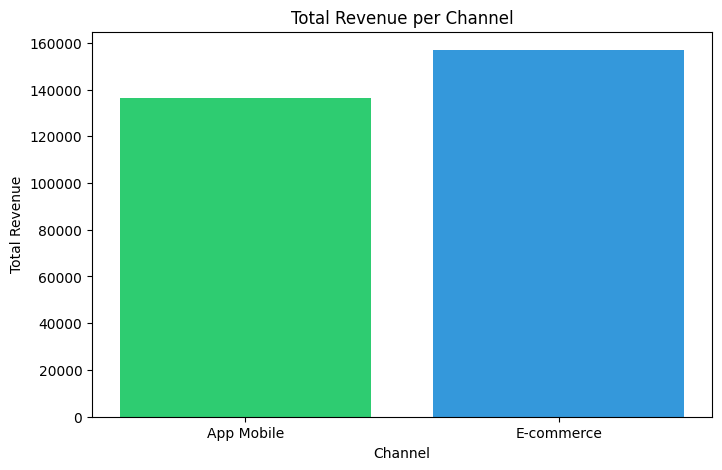

In [35]:
import matplotlib.pyplot as plt

sales_by_channel = fact_sales.merge(
    dim_channel[['channel_key', 'channel']], on='channel_key'
).groupby('channel').agg(
    total_revenue=('item_total', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

print(sales_by_channel)

plt.figure(figsize=(8, 5))
plt.bar(sales_by_channel['channel'], sales_by_channel['total_revenue'], color=['#2ecc71', '#3498db'])
plt.title('Total Revenue per Channel')
plt.xlabel('Channel')
plt.ylabel('Total Revenue')
plt.savefig('revenue_by_channel.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Penjualan per Negara

**Pertanyaan:** Negara mana yang memberikan kontribusi penjualan terbesar?

       country  total_revenue
1      Germany       67320.43
0       France       66524.62
2        Italy       54073.47
3  Netherlands       43128.36
5        Spain       36582.16
4     Portugal       25799.22


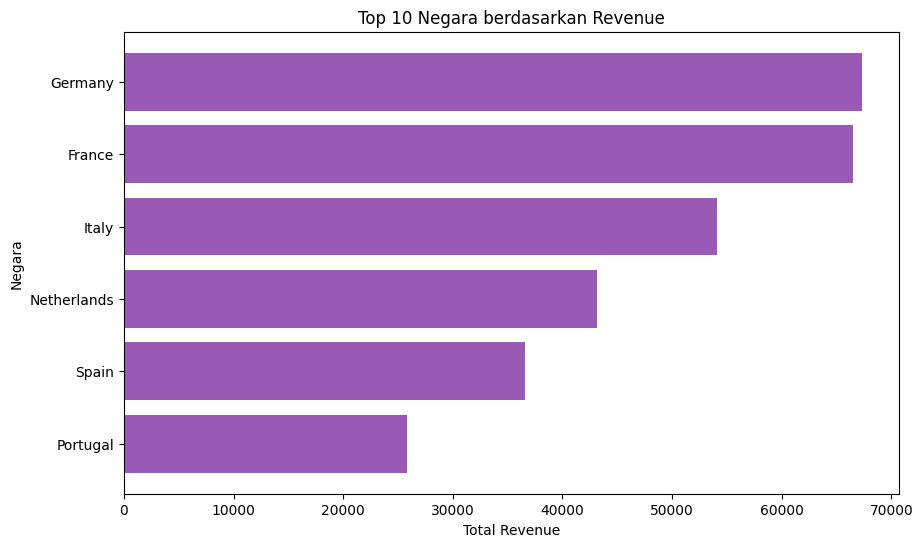

In [36]:
sales_by_country = fact_sales.merge(
    dim_customer[['customer_key', 'country']], on='customer_key'
).groupby('country').agg(total_revenue=('item_total', 'sum')).reset_index()
sales_by_country = sales_by_country.sort_values('total_revenue', ascending=False).head(10)

print(sales_by_country)

plt.figure(figsize=(10, 6))
plt.barh(sales_by_country['country'], sales_by_country['total_revenue'], color='#9b59b6')
plt.title('Top 10 Negara berdasarkan Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Negara')
plt.gca().invert_yaxis()
plt.savefig('revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Penjualan per Kategori Produk

**Pertanyaan:** Kategori produk mana yang paling laku?

    category  total_revenue
2      Shoes       64343.64
4   T-Shirts       62519.91
0    Dresses       61696.17
3  Sleepwear       55678.71
1      Pants       49189.83


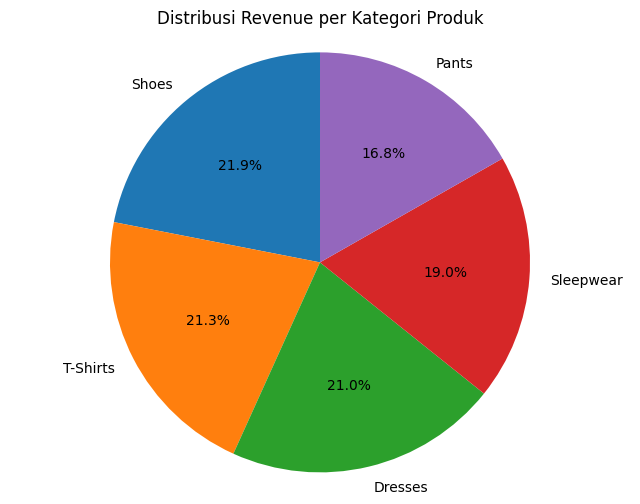

In [37]:
sales_by_category = fact_sales.merge(
    dim_product[['product_key', 'category']], on='product_key'
).groupby('category').agg(total_revenue=('item_total', 'sum')).reset_index()
sales_by_category = sales_by_category.sort_values('total_revenue', ascending=False)

print(sales_by_category)

plt.figure(figsize=(8, 6))
plt.pie(sales_by_category['total_revenue'], labels=sales_by_category['category'], autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Revenue per Kategori Produk')
plt.axis('equal')
plt.savefig('revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Tren Penjualan Bulanan

**Pertanyaan:** Bagaimana tren penjualan dari bulan ke bulan?

   year  month month_name  total_revenue      period
0  2025      4      April      122147.59  April 2025
1  2025      5        May      131587.94    May 2025
2  2025      6       June       39692.73   June 2025


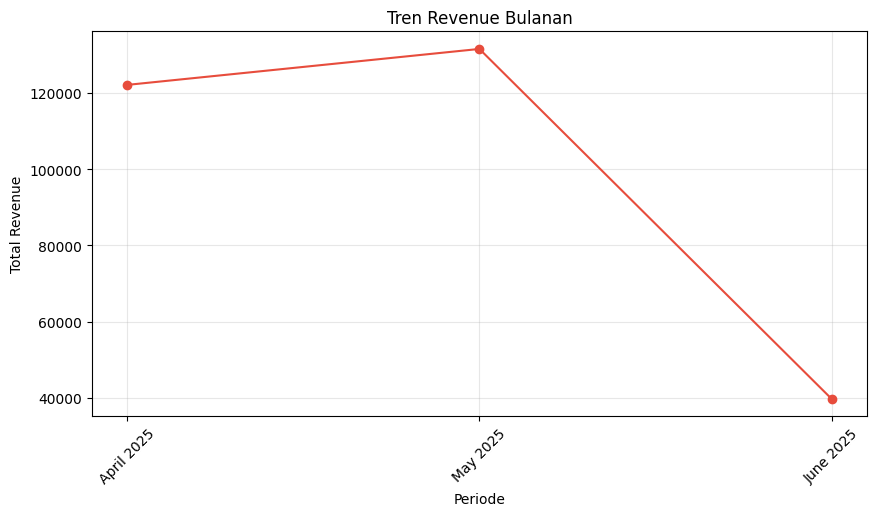

In [38]:
fact_sales['date_key'] = fact_sales['date_key'].astype(int)
dim_date['date_key'] = dim_date['date_key'].astype(int)
monthly = fact_sales.merge(
    dim_date[['date_key', 'year', 'month', 'month_name']], on='date_key'
)
monthly_trend = monthly.groupby(['year', 'month', 'month_name']).agg(
    total_revenue=('item_total', 'sum')
).reset_index()
monthly_trend['period'] = monthly_trend['month_name'] + ' ' + monthly_trend['year'].astype(str)

print(monthly_trend)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend['period'], monthly_trend['total_revenue'], marker='o', color='#e74c3c')
plt.title('Tren Revenue Bulanan')
plt.xlabel('Periode')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig('revenue_trend_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Penjualan per Rentang Usia

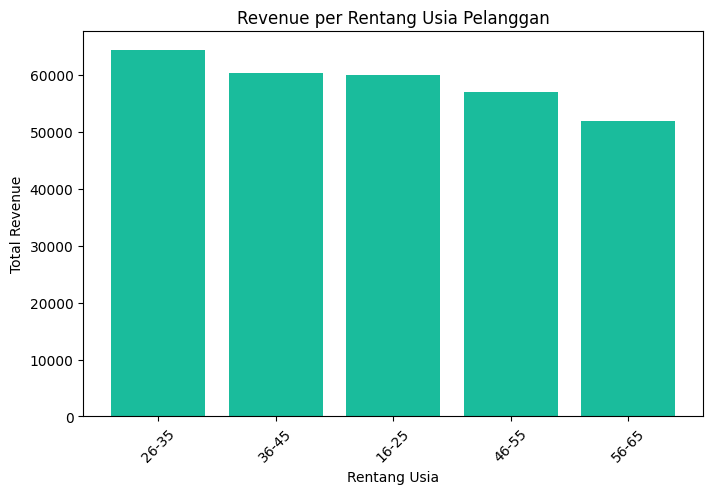

In [39]:
sales_by_age = fact_sales.merge(
    dim_customer[['customer_key', 'age_range']], on='customer_key'
).groupby('age_range').agg(total_revenue=('item_total', 'sum')).reset_index()
sales_by_age = sales_by_age.sort_values('total_revenue', ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(sales_by_age['age_range'], sales_by_age['total_revenue'], color='#1abc9c')
plt.title('Revenue per Rentang Usia Pelanggan')
plt.xlabel('Rentang Usia')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.savefig('revenue_by_age.png', dpi=150, bbox_inches='tight')
plt.show()